In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


In [4]:
!pip install faiss-cpu #install FAISS

import pandas as pd 
import numpy as np 
import faiss 
from sentence_transformers import SentenceTransformer, CrossEncoder 
from transformers import AutoTokenizer, pipeline 
from sklearn.feature_extraction.text import TfidfVectorizer 
from sklearn.metrics.pairwise import cosine_similarity 

train = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv') 

print("Creating knowledge base")
kb = [] 
for idx, row in train.iterrows(): 
    correct_letter = row['answer'] 
    kb.append(str(row[correct_letter])) 

print("Loading embedding model and creating index") 
model = SentenceTransformer('all-MiniLM-L6-v2') 
kb_embeddings = model.encode(kb, show_progress_bar=False) 
index = faiss.IndexFlatL2(kb_embeddings.shape[1]) 
index.add(kb_embeddings)

print("Knowledge base successfully created")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 66.0 MB/s eta 0:00:00:00:0100:01


Creating knowledge base
Loading embedding model and creating index


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Knowledge base successfully created


In [5]:
zs = pipeline("zero-shot-classification", model="facebook/bart-large-mnli") 
row_150 = train.iloc[150] 
prompt_150 = str(row_150['prompt']) 
labels_150 = [str(row_150['A']), str(row_150['B']), str(row_150['C']), str(row_150['D']), str(row_150['E'])] 
ans_150 = str(row_150[row_150['answer']])

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

####  ***Q1. Run the zero-shot classifier on facebook/bart-large-mnli on prompt for the row index 150. Pass the 5 options (A-E) candidate_labels. What is the predicted probability score assigned to the ground-truth correct option (option in the answer column)? (Round to 3 decimal points)***

In [6]:
results=zs(prompt_150,labels_150)

In [7]:
results

{'sequence': 'Select the most accurate option: What is the butterfly effect, as defined by Lorenz in his book "The Essence of Chaos"? based on the given context.',
 'labels': ['The butterfly effect is the phenomenon that a small change in the initial conditions of a dynamical framework can cause significant distinctions in subsequent states, as defined by Lorenz in his book "The Essence of Chaos."',
  'The butterfly effect is the phenomenon that a large change in the initial conditions of a dynamical mechanism can cause significant distinctions in subsequent states, as defined by Lorenz in his book "The Essence of Chaos."',
  'The butterfly effect is the phenomenon that a small change in the initial conditions of a dynamical mechanism can cause subsequent states to differ greatly from the states that would have followed without the alteration, as defined by Einstein in his book "The concept of Relativity."',
  'The butterfly effect is the phenomenon that a small change in the initial c

In [8]:
round(max(results['scores']),3)

0.384

####  ***Q2. Embed the prompt for row index 150 using all-MiniLM-L6-v2. Query your FAISS index to retrieve the top k=10 most similar documents. At what exact rank (1 through 10) did FAISS place the true correct document (which is the document originally located at index 150 in the KB)?***

In [9]:
prompt_150 

'Select the most accurate option: What is the butterfly effect, as defined by Lorenz in his book "The Essence of Chaos"? based on the given context.'

In [10]:
kb[150]

'The butterfly effect is the phenomenon that a small change in the initial conditions of a dynamical framework can cause significant distinctions in subsequent states, as defined by Lorenz in his book "The Essence of Chaos."'

In [11]:
Query_embedding = model.encode([prompt_150])

In [12]:
Query_embedding.shape

(1, 384)

In [13]:
k=10
dist,indx = index.search(Query_embedding,k)

In [14]:
dist,indx

(array([[0.26394254, 0.26394254, 0.2664283 , 0.2664283 , 0.26862192,
         0.2699363 , 0.2699363 , 0.2699363 , 0.28316107, 0.28714603]],
       dtype=float32),
 array([[ 663, 1701, 1269, 1532,  576,  847, 1693, 1906,  168,  150]]))

In [15]:
dist[0]

array([0.26394254, 0.26394254, 0.2664283 , 0.2664283 , 0.26862192,
       0.2699363 , 0.2699363 , 0.2699363 , 0.28316107, 0.28714603],
      dtype=float32)

In [16]:
indx[0]

array([ 663, 1701, 1269, 1532,  576,  847, 1693, 1906,  168,  150])

In [17]:
import seaborn as sns


import matplotlib.pyplot as plt

<Axes: >

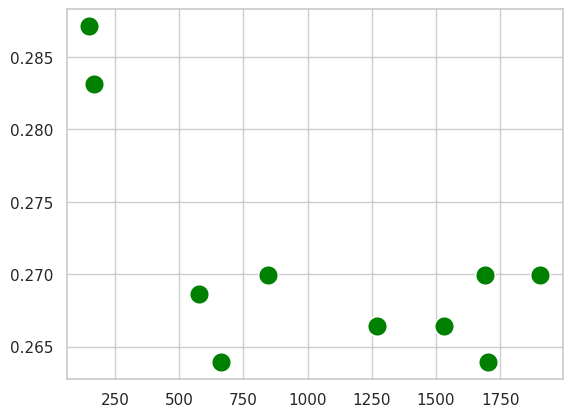

In [18]:
sns.set(style="whitegrid")


sns.scatterplot(x=indx[0],y=dist[0],color='green',s=200)



In [19]:
from sentence_transformers import CrossEncoder

In [20]:
retrieved_indices=indx[0]

#### ***Q3. Take the top 10 documents retrieved by FAISS in the previous question. Load cross-encoder/ms-marco-MiniLM-L-6-v2. Score the prompt against these 10 documents and sort them by the cross-encoder's score. At what exact rank (1 through 10) does the Cross-Encoder place the true correct document?***

In [21]:
cross_encoder = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')
docs_10 = [kb[i] for i in retrieved_indices] #Get the top 10 chunks
pairs = [[prompt_150, doc] for doc in docs_10] #Create prompt-context pairs
ce_scores = cross_encoder.predict(pairs) # Get the score of each pai

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

In [22]:
ce_scores

array([4.6602316, 4.6602316, 4.7375226, 4.7375226, 4.6870446, 4.7525764,
       4.7525764, 4.7525764, 4.7072477, 4.758512 ], dtype=float32)

In [23]:
max(ce_scores)

np.float32(4.758512)

In [24]:
retrieved_indices[np.argsort(ce_scores)]

array([ 663, 1701,  576,  168, 1532, 1269, 1693,  847, 1906,  150])

In [25]:
retrieved_indices[max(np.argsort(ce_scores))]

np.int64(150)

In [26]:
true_doc = 150

reranked_docs = retrieved_indices[np.argsort(ce_scores)[::-1]]

rank = list(reranked_docs).index(true_doc) + 1

print("CrossEncoder Rank:", rank)

CrossEncoder Rank: 1


#### ***Q4. Retrieve the top k=5 documents for the prompt at row index 42. Concatenate them with a single space between each. Create a string: "Context: [concatenated_docs] Question: [prompt]". Tokenize this string using the bert-base-uncased tokenizer (without truncation). Exactly how many total tokens does this generate?***

In [27]:
prompt = train.iloc[42]["prompt"]

In [28]:
prompt

'Choose the correct answer: What are permutation-inversion groups? based on the given context.'

In [29]:
query_encode = model.encode([prompt])

In [30]:
query_encode.shape

(1, 384)

In [31]:
x,y = index.search(query_encode, 5)

In [32]:
x,y

(array([[0.4061649, 0.4061649, 0.4061649, 0.4061649, 0.4061649]],
       dtype=float32),
 array([[241, 439, 456, 506, 605]]))

In [33]:
y[0]

array([241, 439, 456, 506, 605])

In [34]:
docs = [kb[i] for i in y[0] ]

docs

['Permutation-inversion groups are groups of symmetry operations that are energetically feasible permutations of identical nuclei or inversion with respect to the center of mass, or a combination of both.',
 'Permutation-inversion groups are groups of symmetry operations that are energetically feasible permutations of identical nuclei or inversion with respect to the center of mass, or a combination of both.',
 'Permutation-inversion groups are groups of symmetry operations that are energetically feasible permutations of identical nuclei or inversion with respect to the center of mass, or a combination of both.',
 'Permutation-inversion groups are groups of symmetry operations that are energetically feasible permutations of identical nuclei or inversion with respect to the center of mass, or a combination of both.',
 'Permutation-inversion groups are groups of symmetry operations that are energetically feasible permutations of identical nuclei or inversion with respect to the center of

In [35]:
context = " ".join(docs)

In [37]:
text = f"Context: {context} Question: {prompt}"

In [38]:
text

'Context: Permutation-inversion groups are groups of symmetry operations that are energetically feasible permutations of identical nuclei or inversion with respect to the center of mass, or a combination of both. Permutation-inversion groups are groups of symmetry operations that are energetically feasible permutations of identical nuclei or inversion with respect to the center of mass, or a combination of both. Permutation-inversion groups are groups of symmetry operations that are energetically feasible permutations of identical nuclei or inversion with respect to the center of mass, or a combination of both. Permutation-inversion groups are groups of symmetry operations that are energetically feasible permutations of identical nuclei or inversion with respect to the center of mass, or a combination of both. Permutation-inversion groups are groups of symmetry operations that are energetically feasible permutations of identical nuclei or inversion with respect to the center of mass, o

In [39]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [40]:
tokens = tokenizer(text, truncation=False)

In [41]:
len(tokens['input_ids'])

216

#### ***Q5. Retrieve the exact true document for row index 150 from your KB. Create a RAG string: "Context: [true_document] Question: [prompt]". Run the same zero-shot classification from Question 1 on this augmented string. What is the new predicted probability score of the ground-truth correct option? (Round to 3 decimal places).***

In [42]:
row_150 = train.iloc[150]

In [43]:
prompt_150=row_150['prompt']

In [44]:
true_document = kb[150]

In [45]:
true_document

'The butterfly effect is the phenomenon that a small change in the initial conditions of a dynamical framework can cause significant distinctions in subsequent states, as defined by Lorenz in his book "The Essence of Chaos."'

In [46]:
rag_string= f"Context: {true_document} Question: {prompt_150}"

In [47]:
rag_string

'Context: The butterfly effect is the phenomenon that a small change in the initial conditions of a dynamical framework can cause significant distinctions in subsequent states, as defined by Lorenz in his book "The Essence of Chaos." Question: Select the most accurate option: What is the butterfly effect, as defined by Lorenz in his book "The Essence of Chaos"? based on the given context.'

In [48]:
zs = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli"
)

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

In [50]:
row_150 = train.iloc[150] 
prompt_150 = str(row_150['prompt']) 
labels_150 = [str(row_150['A']), str(row_150['B']), str(row_150['C']), str(row_150['D']), str(row_150['E'])] 
ans_150 = str(row_150[row_150['answer']])

In [51]:
result = zs(rag_string, labels_150)

In [52]:
result

{'sequence': 'Context: The butterfly effect is the phenomenon that a small change in the initial conditions of a dynamical framework can cause significant distinctions in subsequent states, as defined by Lorenz in his book "The Essence of Chaos." Question: Select the most accurate option: What is the butterfly effect, as defined by Lorenz in his book "The Essence of Chaos"? based on the given context.',
 'labels': ['The butterfly effect is the phenomenon that a small change in the initial conditions of a dynamical framework can cause significant distinctions in subsequent states, as defined by Lorenz in his book "The Essence of Chaos."',
  'The butterfly effect is the phenomenon that a large change in the initial conditions of a dynamical mechanism can cause significant distinctions in subsequent states, as defined by Lorenz in his book "The Essence of Chaos."',
  'The butterfly effect is the phenomenon that a small change in the initial conditions of a dynamical structure has no effec

In [53]:
ground_truth = ans_150
ground_truth

'The butterfly effect is the phenomenon that a small change in the initial conditions of a dynamical framework can cause significant distinctions in subsequent states, as defined by Lorenz in his book "The Essence of Chaos."'

In [54]:
idx = result["labels"].index(ground_truth)

idx

0

In [55]:
print(round(result["scores"][idx], 3))

0.989


#### ***Q6. What happens if your vector database retrieves the wrong information? Take the prompt for row index 150. Manually force the context to be the document located at KB index 999 (a completely unrelated fact). Run the zero-shot classifier on this "Adversarial RAG" string. What is the probability of the correct option now? (Round to 3 decimal places).***

In [56]:
row_150 = train.iloc[150] 
prompt_150 = str(row_150['prompt']) 
labels_150 = [str(row_150['A']), str(row_150['B']), str(row_150['C']), str(row_150['D']), str(row_150['E'])] 
ans_150 = str(row_150[row_150['answer']])

In [57]:
true_document = kb[150]

wrong_document = kb[999]

In [58]:
adversarial_rag = f"Context: {wrong_document} Question: {prompt_150}"
adversarial_rag

'Context: A thought experiment in which a demon guards a microscopic trapdoor in a wall separating two parts of a container filled with the same gas at equal temperatures. The demon selectively allows faster-than-average molecules to pass from one side to the other, causing a reduce in temperature in one part and an boost in temperature in the other, contrary to the second law of thermodynamics. Question: Select the most accurate option: What is the butterfly effect, as defined by Lorenz in his book "The Essence of Chaos"? based on the given context.'

In [59]:
results = zs(adversarial_rag,labels_150)

In [61]:
idx = results["labels"].index(ans_150)

idx

0

In [62]:
print("Correct answer:", ans_150)
print("Probability:", round(results["scores"][idx],3))

Correct answer: The butterfly effect is the phenomenon that a small change in the initial conditions of a dynamical framework can cause significant distinctions in subsequent states, as defined by Lorenz in his book "The Essence of Chaos."
Probability: 0.529


#### ***Q7. For the first 100 rows of train.csv (indices 0-99), retrieve the top k=5 documents for each prompt. If the exact string of the row's correct option is found inside any of those 5 retrieved documents, it counts as a hit. What is the exact Hit Rate percentage (0 to 100) for these 100 rows? (Round to 1 decimal place).***

In [63]:
hits = 0

for i in range(100):

    prompt = str(train.iloc[i]["prompt"])

    correct_answer = str(train.iloc[i][train.iloc[i]["answer"]])

    query_embed = model.encode([prompt])
    x,y = index.search(query_embed,5)
    docs= [kb[idx] for idx in y[0]]

    if correct_answer in docs:
        hits+=1

hit_rate = hits/100*100

print(round(hit_rate,1))

73.0


#### ***Q8. Build a loop that processes the first 20 rows (indices 0 through 19) of train.csv.
For each row, your pipeline must do the following in order:

Retrieve: Embed the prompt and retrieve the top k=5 documents from your FAISS Knowledge Base.

Rerank: Pass the prompt and those 5 documents into the ms-marco-MiniLM-L-6-v2 Cross-Encoder. Select the single document with the highest cross-encoder score.

Augment: Create your RAG string exactly formatted as: "Context: [best_document] Question: [prompt]".

Predict: Pass this augmented string to the facebook/bart-large-mnli zero-shot classifier, using the 5 options (A, B, C, D, E) as your candidate_labels.

Score: Look at the probability scores output by the model. Rank the options from highest probability to lowest. Take the top 3 letters (e.g., ['C', 'A', 'E']) and calculate the MAP@3 for that row.

What is the final average MAP@3 score of this state-of-the-art RAG pipeline across these 20 rows? (Round to 3 decimal places).***

In [69]:
score=[]

for i in range(20):
    row=train.iloc[i]
    prompt = str(train.iloc[i]["prompt"])

    correct_answer = str(train.iloc[i][train.iloc[i]["answer"]])

    query_embed = model.encode([prompt])
    x,y = index.search(query_embed,5)
    docs= [kb[idx] for idx in y[0]]
    pairs = [[prompt,doc] for doc in docs]
    ce_scores=cross_encoder.predict(pairs)
    best_doc=docs[np.argmax(ce_scores)]

    rag_string = f"Context: {best_doc} Question: {prompt}"

    labels = [str(row['A']), str(row['B']), str(row['C']), str(row['D']), str(row['E'])] 

    results = zs(rag_string,labels)


    text_to_letter={
        row["A"]:"A",
        row["B"]:"B",
        row["C"]:"C",
        row["D"]:"D",
        row["E"]:"E"
    }

    predicted_letters=[text_to_letter[label]for label in results["labels"][:3]]

    scores.append(map3()


    

    
    
   



['C', 'D', 'A']


In [70]:
results

{'sequence': 'Context: Newton combined tangential motion with the effects of radially directed force or endeavour and expressed the concept of linear inertia. Question: Which of the following is correct? Who proposed the concept of "maximal acceleration"? carefully.',
 'labels': ['Eduardo R. Caianiello',
  'Hideki Yukawa',
  'Max Planck',
  'Albert Einstein',
  'Niels Bohr'],
 'scores': [0.3839118778705597,
  0.2612055838108063,
  0.1296243518590927,
  0.12200986593961716,
  0.10324831306934357]}

In [83]:
import numpy as np

def map3(actual, predicted):
    if actual in predicted:
        return 1/(predicted.index(actual)+1)
    return 0



In [85]:
print(map3(row["answer"],predicted_letters))

1.0


In [88]:

score.append(map3(row["answer"],predicted_letters))

In [89]:
print(round(np.mean(score),3))

1.0
